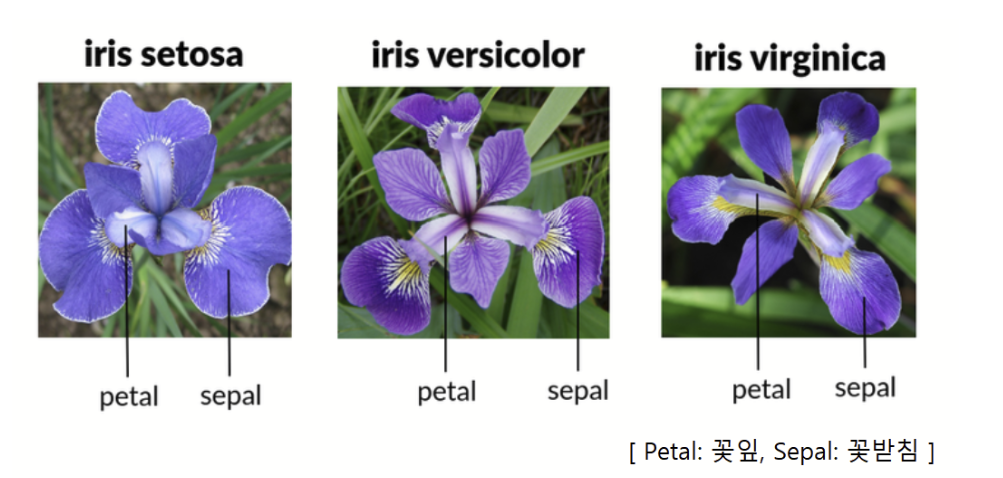

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1️⃣ 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target

# 2️⃣ train/test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================================
# 🔥 1. PCA 없이 (원본 데이터)
# =====================================================

model_raw = LogisticRegression(max_iter=1000)
model_raw.fit(X_train, y_train)

pred_raw = model_raw.predict(X_test)

acc_raw = accuracy_score(y_test, pred_raw)

print("📌 PCA 없이 정확도:", acc_raw)


# =====================================================
# 🔥 2. PCA 적용 후
# =====================================================

# 2-1. 표준화 (중요 ⭐ PCA 전 필수)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2-2. PCA 적용 (4D → 2D)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 2-3. 모델 학습
model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)

pred_pca = model_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test, pred_pca)

print("📌 PCA 적용 후 정확도:", acc_pca)


# =====================================================
# 🔥 3. 설명 분산 확인
# =====================================================

print("\n📊 설명 분산 비율:")
print(pca.explained_variance_ratio_)

print("\n📊 누적 설명 분산:")
print(pca.explained_variance_ratio_.cumsum())

# 결론 한 줄
# 이 PCA는 95% 정보는 유지했지만, 모델 성능은 약간 희생된 좋은 압축 결과다


📌 PCA 없이 정확도: 1.0
📌 PCA 적용 후 정확도: 0.9

📊 설명 분산 비율:
[0.72551423 0.23000922]

📊 누적 설명 분산:
[0.72551423 0.95552345]


| 기준    | 평가      |
| ----- | ------- |
| < 90% | 부족 ❌    |
| ~95%  | 적절 👍   |
| > 95% | 매우 좋음 ⭐ |
